In [38]:
print("Hello World!!")

Hello World!!


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [40]:
df = pd.read_excel(r"/Users/developer/Documents/Current Project/Python/DevArena /Arena-Week-8-CapstoneProject/data/cleaned_data.xlsx")
df

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale,Region,Quarter,TimeOfDay
0,536365,85123A,6,2.55,17850,United Kingdom,08:26:00,2010,12,1,15.30,Europe,Q4,Morning
1,536365,71053,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
2,536365,84406B,8,2.75,17850,United Kingdom,08:26:00,2010,12,1,22.00,Europe,Q4,Morning
3,536365,84029G,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
4,536365,84029E,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324554,581587,22613,12,0.85,12680,France,12:50:00,2011,12,9,10.20,Europe,Q4,Afternoon
324555,581587,22899,6,2.10,12680,France,12:50:00,2011,12,9,12.60,Europe,Q4,Afternoon
324556,581587,23254,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon
324557,581587,23255,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon


##### <b>Null Hypothesis: </b> There is no siginificant difference between the aveage fares between customers from different continents for different quarters. <br>
##### <b>Alternate Hypothesis: </b> There is siginificant difference between the aveage fares between customers from different continents for different quarters.

In [41]:
df_temp = df.groupby(['Region', 'Quarter']).agg(
    total_sales=('LineSale', 'sum')
).reset_index()
df_temp['total_sales'] = round(df_temp['total_sales'], 2)
df_temp

,Region,Quarter,total_sales
0,Africa,Q4,734.36
1,Asia,Q1,711.58
2,Asia,Q2,425.10
3,Asia,Q3,538.02
4,Asia,Q4,885.14
5,Europe,Q1,596379.10
6,Europe,Q2,686092.15
7,Europe,Q3,844998.47
8,Europe,Q4,1278475.15
9,Middle East,Q1,3716.27


In [42]:
pivot_df_temp = df_temp.pivot(index='Region', columns='Quarter', values='total_sales').sort_values(by='Q1', ascending=False)[1:]
pivot_df_temp.fillna(0.00, inplace=True)

Quarter,Q1,Q2,Q3,Q4
Region,,,,
Middle East,3716.27,805.47,2828.20,3604.94
Oceania,2036.28,1124.52,2751.90,859.30
Asia,711.58,425.10,538.02,885.14
North America,140.54,983.38,1049.47,2271.26
Africa,0.00,0.00,0.00,734.36
Other,0.00,1129.04,853.04,0.00
South America,0.00,317.34,0.00,0.00


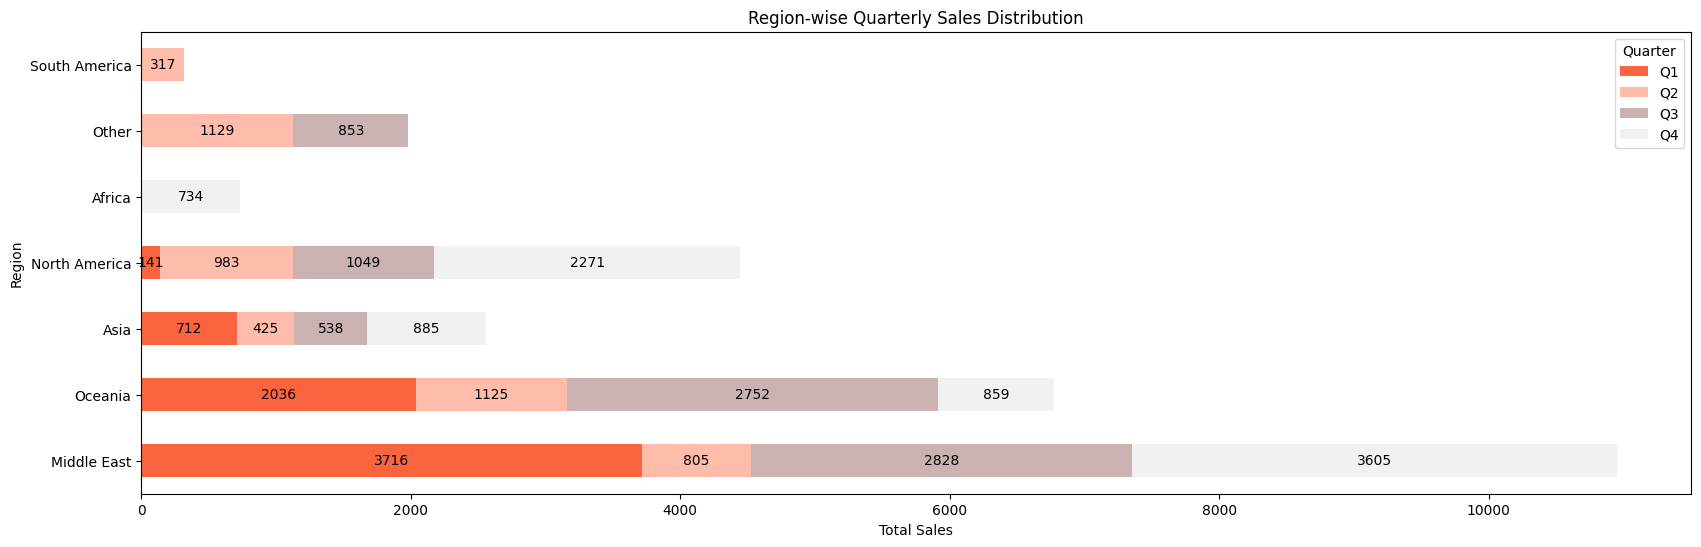

In [43]:
fig, ax = plt.subplots(figsize=(20, 6))

pivot_df_temp.plot(
    kind='barh',          # horizontal bars
    stacked=True,         # stacked like your example
    ax=ax,
    color=['#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F', '#F1C0C0', '#F1C0C0', '#F1C0C0', '#F1C0C0', '#F1C0C0']
)

# Labels
ax.set_xlabel("Total Sales")
ax.set_ylabel("Region")
ax.set_title("Region-wise Quarterly Sales Distribution")

# Add value labels inside bars
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if width > 0:  # avoid labeling zero values
        ax.text(
            x + width / 2,
            y + height / 2,
            f'{width:.0f}',
            ha='center',
            va='center'
        )

plt.legend(title="Quarter")
plt.show()

In [44]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
df_temp = df.copy()
# Two-way ANOVA
model = ols('LineSale ~ C(Region) + C(Quarter) + C(Region):C(Quarter)', data=df_temp).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Region),3.130613e-02,7.0,0.000067,1.000000
C(Quarter),1.495403e-02,3.0,0.000075,0.993104
C(Region):C(Quarter),1.826613e+03,21.0,1.303625,0.259016
Residual,2.130800e+07,319351.0,NaN,NaN


Although there appear to be differences in aggregate sales, high within-group variability and skewness reduce statistical significance. A log transformation can stabilize variance and provide more reliable inference.

We <b>fail to reject Null Hypothesis</b>

##### <b>Null Hypothesis: </b> There is no siginificant difference between the aveage fares between different times of the day. <br>
##### <b>Alternate Hypothesis: </b> There is siginificant difference between the aveage fares between between different times of the day.

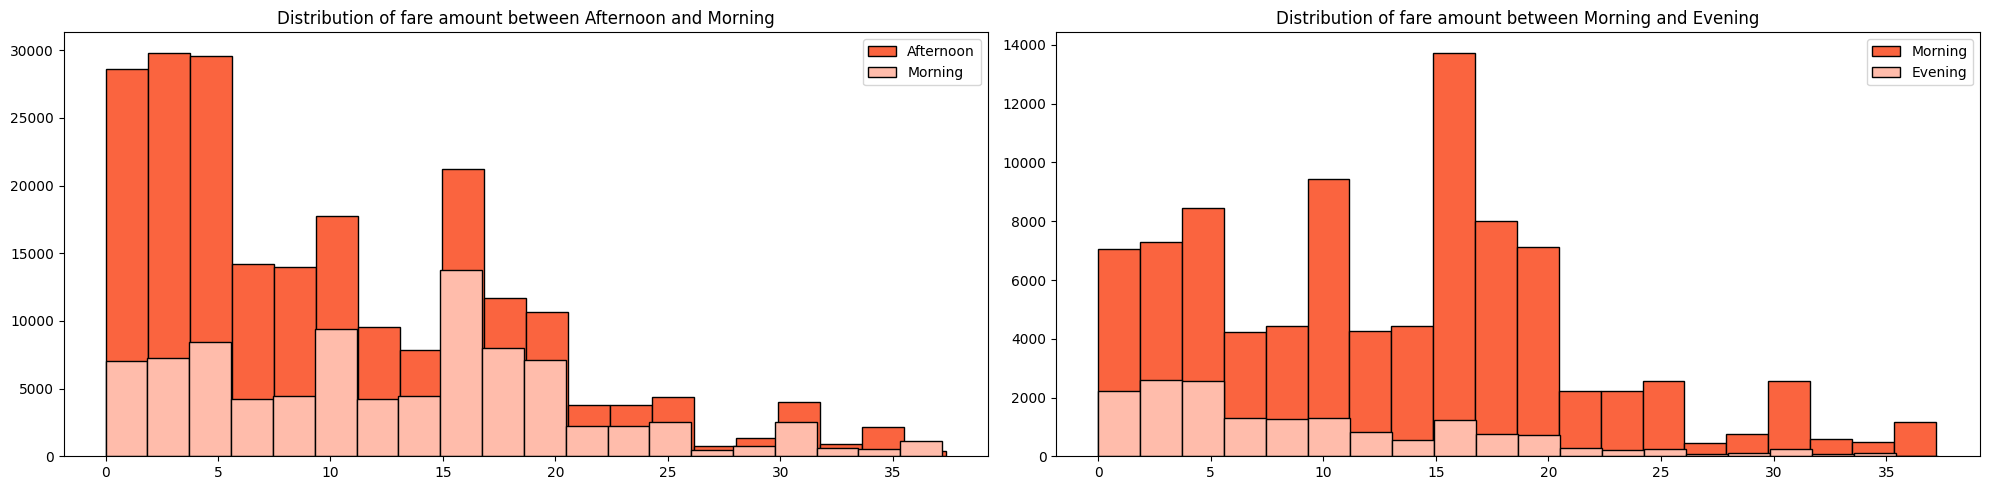

In [45]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.title("Distribution of fare amount between Afternoon and Morning")
plt.hist(df[df['TimeOfDay'] == 'Afternoon']['LineSale'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Afternoon')
plt.hist(df[df['TimeOfDay'] == 'Morning']['LineSale'], histtype= 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Morning')
plt.legend()
plt.subplot(1, 2, 2)
plt.title("Distribution of fare amount between Morning and Evening")
plt.hist(df[df['TimeOfDay'] == 'Morning']['LineSale'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Morning')
plt.hist(df[df['TimeOfDay'] == 'Evening']['LineSale'], histtype= 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Evening')
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
morning_sample = df[df['TimeOfDay'] == 'Morning']['LineSale']
afternoon_sample = df[df['TimeOfDay'] == 'Afternoon']['LineSale']
evening_sample = df[df['TimeOfDay'] == 'Evening']['LineSale']

In [47]:
from scipy.stats import f_oneway

In [48]:
f_stats, p_stats = f_oneway(morning_sample, afternoon_sample, evening_sample)

In [49]:
print(f"F-statistic: {f_stats:.2f}")
print(f"P-value: {p_stats:.2f}")

F-statistic: 4434.15
P-value: 0.00


We <b>reject Null Hypothesis</b>

##### <b>Null Hypothesis: </b> There is no siginificant difference between the aveage fares between different quarters. <br>
##### <b>Alternate Hypothesis: </b> There is siginificant difference between the aveage fares between between different quarters.

In [50]:
q1_sample = df[df['Quarter'] == 'Q1']['LineSale']
q2_sample = df[df['Quarter'] == 'Q2']['LineSale']
q3_sample = df[df['Quarter'] == 'Q3']['LineSale']
q4_sample = df[df['Quarter'] == 'Q4']['LineSale']

In [51]:
from scipy.stats import f_oneway

In [52]:
f_stats, p_stats = f_oneway(q1_sample, q2_sample, q3_sample, q4_sample)

In [53]:
print(f"F-statistic: {f_stats:.2f}")
print(f"P-value: {p_stats:.2f}")

F-statistic: 702.34
P-value: 0.00


We <b>reject Null Hypothesis</b>